# 03 — Feature Engineering

**Objectif :** transformer les données brutes de `v_delays_enriched` en un dataset Parquet prêt pour XGBoost.

**Ce qu'on fait ici :**
1. Charger et explorer les données depuis PostGIS
2. Analyser la distribution des délais et des features
3. Générer le dataset final avec `build_feature_dataset()`
4. Valider la qualité du dataset
5. Export en Parquet

## 0. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sqlalchemy import text

from src.utils.db import engine
from src.models.features import build_feature_dataset, FEATURE_COLUMNS, TARGET_COLUMN

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)

print('Setup OK')

Setup OK


## 1. Aperçu des données collectées

In [2]:
# Vue d'ensemble des tables
with engine.connect() as conn:
    stats = conn.execute(text("""
        SELECT
            (SELECT COUNT(*) FROM stop_delays)      AS stop_delays,
            (SELECT COUNT(*) FROM weather_snapshots) AS weather_snapshots,
            (SELECT COUNT(*) FROM vehicle_positions) AS vehicle_positions,
            (SELECT COUNT(*) FROM v_delays_enriched WHERE temperature_c IS NOT NULL) AS enriched_joinable
    """)).fetchone()

print(f"stop_delays       : {stats.stop_delays:>10,} lignes")
print(f"weather_snapshots : {stats.weather_snapshots:>10,} lignes")
print(f"vehicle_positions : {stats.vehicle_positions:>10,} lignes")
print(f"v_delays_enriched : {stats.enriched_joinable:>10,} lignes (avec météo)")

stop_delays       : 96,929,046 lignes
weather_snapshots :        172 lignes
vehicle_positions :    688,822 lignes
v_delays_enriched : 96,929,046 lignes (avec météo)


In [3]:
# Couverture temporelle
with engine.connect() as conn:
    coverage = conn.execute(text("""
        SELECT
            MIN(collected_at) AT TIME ZONE 'America/Montreal' AS debut,
            MAX(collected_at) AT TIME ZONE 'America/Montreal' AS fin,
            ROUND(EXTRACT(EPOCH FROM (MAX(collected_at) - MIN(collected_at))) / 3600, 1) AS heures
        FROM stop_delays
    """)).fetchone()

print(f"Début   : {coverage.debut}")
print(f"Fin     : {coverage.fin}")
print(f"Durée   : {coverage.heures}h")

Début   : 2026-04-02 09:17:26.276483
Fin     : 2026-04-03 21:20:04.247289
Durée   : 36.0h


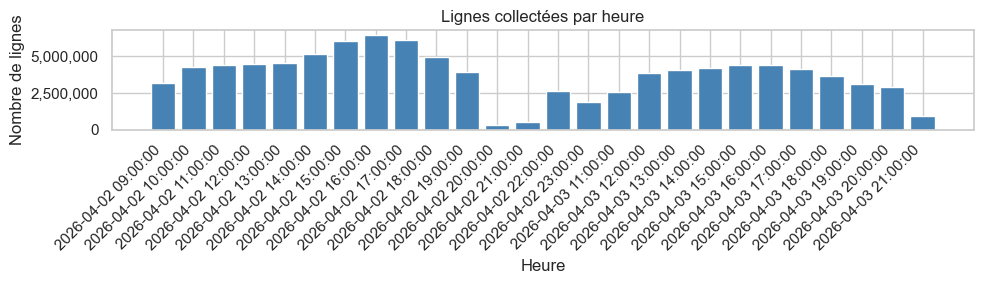

              heure  lignes
2026-04-02 09:00:00 3190852
2026-04-02 10:00:00 4271752
2026-04-02 11:00:00 4364664
2026-04-02 12:00:00 4448197
2026-04-02 13:00:00 4551406
2026-04-02 14:00:00 5131268
2026-04-02 15:00:00 6019995
2026-04-02 16:00:00 6417022
2026-04-02 17:00:00 6058884
2026-04-02 18:00:00 4938986
2026-04-02 19:00:00 3901213
2026-04-02 20:00:00  360111
2026-04-02 21:00:00  536487
2026-04-02 22:00:00 2667048
2026-04-02 23:00:00 1883224
2026-04-03 11:00:00 2555653
2026-04-03 12:00:00 3857783
2026-04-03 13:00:00 4035769
2026-04-03 14:00:00 4207452
2026-04-03 15:00:00 4385715
2026-04-03 16:00:00 4372517
2026-04-03 17:00:00 4153842
2026-04-03 18:00:00 3619835
2026-04-03 19:00:00 3121125
2026-04-03 20:00:00 2924482
2026-04-03 21:00:00  953764


In [4]:
# Distribution par heure — repérer les trous éventuels
with engine.connect() as conn:
    hourly = pd.read_sql(text("""
        SELECT
            date_trunc('hour', collected_at AT TIME ZONE 'America/Montreal') AS heure,
            COUNT(*) AS lignes
        FROM stop_delays
        GROUP BY 1
        ORDER BY 1
    """), conn)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(hourly['heure'].astype(str), hourly['lignes'], color='steelblue')
ax.set_title('Lignes collectées par heure')
ax.set_xlabel('Heure')
ax.set_ylabel('Nombre de lignes')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(hourly.to_string(index=False))

## 2. Exploration des délais bruts

In [5]:
# Échantillon pour l'exploration (1% des données)
with engine.connect() as conn:
    df_sample = pd.read_sql(text("""
        SELECT *
        FROM v_delays_enriched
        WHERE temperature_c IS NOT NULL
        AND RANDOM() < 0.01
    """), conn)

print(f"{len(df_sample):,} lignes dans l'échantillon")
df_sample.head()

969,200 lignes dans l'échantillon


,id,route_id,stop_id,scheduled_at,delay_seconds,hour_of_day,day_of_week,week_of_year,is_rush_hour,temperature_c,precipitation_mm,wind_speed_kmh,is_precipitation
0,13818669,32,61546,2026-04-02 13:18:05+00:00,146,9.00,4.00,14.00,True,0.30,0.00,15.60,False
1,13818746,41,50357,2026-04-02 14:05:40+00:00,0,10.00,4.00,14.00,False,0.30,0.00,15.60,False
2,13818847,165,52201,2026-04-02 13:29:00+00:00,0,9.00,4.00,14.00,True,0.30,0.00,15.60,False
3,13818914,189,53596,2026-04-02 13:20:16+00:00,-42,9.00,4.00,14.00,True,0.30,0.00,15.60,False
4,13819027,119,56064,2026-04-02 13:24:30+00:00,62,9.00,4.00,14.00,True,0.30,0.00,15.60,False


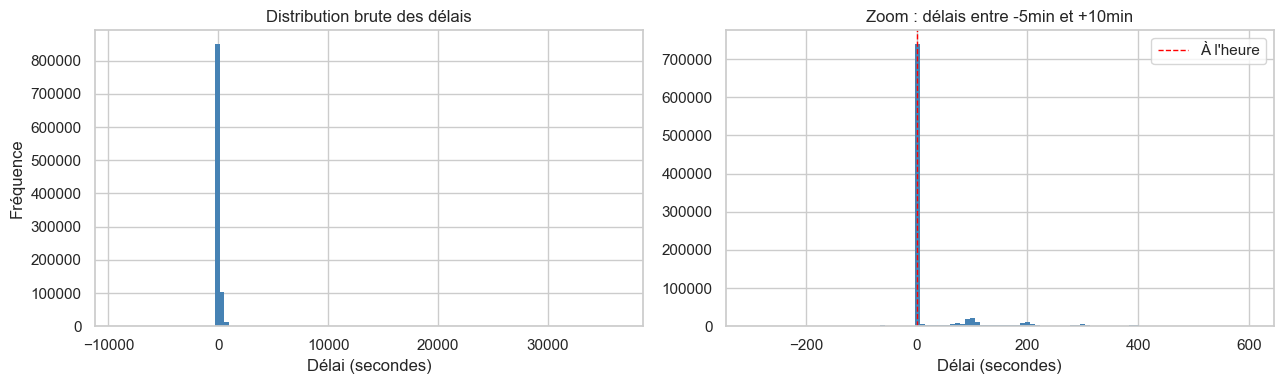

Statistiques des délais :
count   969200.00
mean        47.60
std        199.75
min      -8960.00
25%          0.00
50%          0.00
75%          0.00
max      36401.00
Name: delay_seconds, dtype: float64


In [6]:
# Distribution des délais bruts (avec outliers)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_sample['delay_seconds'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Distribution brute des délais')
axes[0].set_xlabel('Délai (secondes)')
axes[0].set_ylabel('Fréquence')

# Zoom sur [-300s, +600s] pour voir la masse principale
df_zoom = df_sample[df_sample['delay_seconds'].between(-300, 600)]
axes[1].hist(df_zoom['delay_seconds'], bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Zoom : délais entre -5min et +10min')
axes[1].set_xlabel('Délai (secondes)')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1, label='À l\'heure')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Statistiques des délais :")
print(df_sample['delay_seconds'].describe())

In [7]:
# Pourcentage d'outliers (|delay| > 1h) — seront supprimés dans features.py
total = len(df_sample)
outliers = len(df_sample[~df_sample['delay_seconds'].between(-600, 3600)])
print(f"Outliers (|délai| > 1h) : {outliers:,} / {total:,} = {outliers/total*100:.2f}%")

Outliers (|délai| > 1h) : 433 / 969,200 = 0.04%


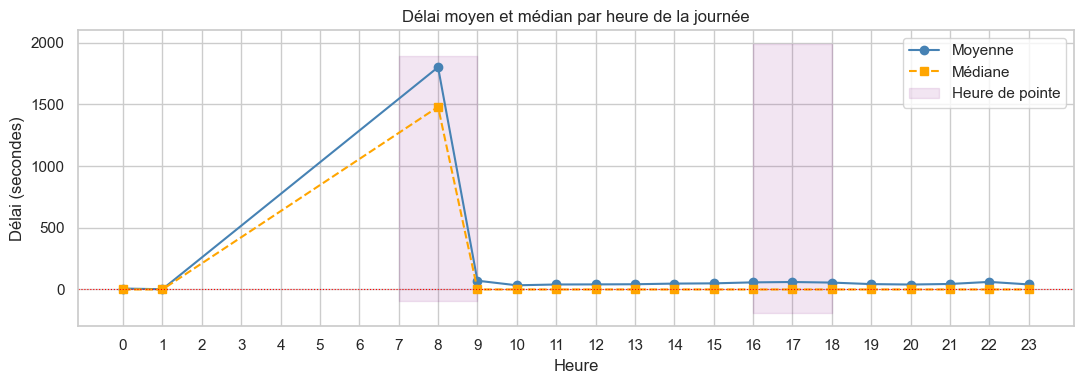

In [8]:
# Délais moyens par heure de la journée
with engine.connect() as conn:
    by_hour = pd.read_sql(text("""
        SELECT
            hour_of_day,
            AVG(delay_seconds) AS avg_delay,
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY delay_seconds) AS median_delay,
            COUNT(*) AS n
        FROM v_delays_enriched
        WHERE delay_seconds BETWEEN -600 AND 3600
          AND temperature_c IS NOT NULL
        GROUP BY 1
        ORDER BY 1
    """), conn)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(by_hour['hour_of_day'], by_hour['avg_delay'], marker='o', label='Moyenne', color='steelblue')
ax.plot(by_hour['hour_of_day'], by_hour['median_delay'], marker='s', linestyle='--', label='Médiane', color='orange')
ax.axhline(0, color='red', linewidth=0.8, linestyle=':')
ax.fill_between([7, 9], ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color='purple', label='Heure de pointe')
ax.fill_between([16, 18], ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color='purple')
ax.set_title('Délai moyen et médian par heure de la journée')
ax.set_xlabel('Heure')
ax.set_ylabel('Délai (secondes)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

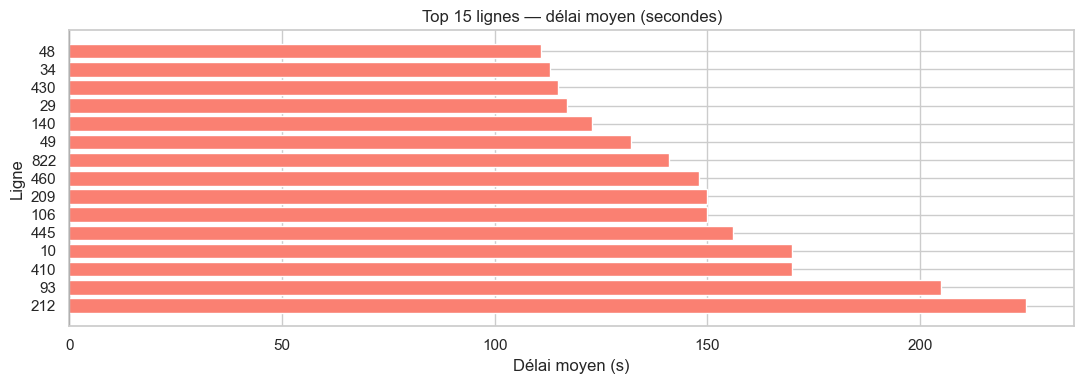

route_id  avg_delay  std_delay       n
     212     225.00     565.00  149288
      93     205.00     455.00  280320
     410     170.00     255.00   63589
      10     170.00     315.00  389662
     445     156.00     284.00   58827
     106     150.00     447.00  731346
     209     150.00     410.00  479713
     460     148.00     413.00  390325
     822     141.00     401.00   48697
      49     132.00     248.00 1847965
     140     123.00     244.00  667617
      29     117.00     216.00  350484
     430     115.00     256.00  129778
      34     113.00     266.00  400105
      48     111.00     222.00 1637318


In [9]:
# Top 10 lignes les plus en retard
with engine.connect() as conn:
    by_route = pd.read_sql(text("""
        SELECT
            route_id,
            ROUND(AVG(delay_seconds)) AS avg_delay,
            ROUND(STDDEV(delay_seconds)) AS std_delay,
            COUNT(*) AS n
        FROM v_delays_enriched
        WHERE delay_seconds BETWEEN -600 AND 3600
          AND temperature_c IS NOT NULL
        GROUP BY 1
        HAVING COUNT(*) > 100
        ORDER BY avg_delay DESC
        LIMIT 15
    """), conn)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(by_route['route_id'].astype(str), by_route['avg_delay'], color='salmon')
ax.set_title('Top 15 lignes — délai moyen (secondes)')
ax.set_xlabel('Délai moyen (s)')
ax.set_ylabel('Ligne')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print(by_route.to_string(index=False))

## 3. Analyse des features

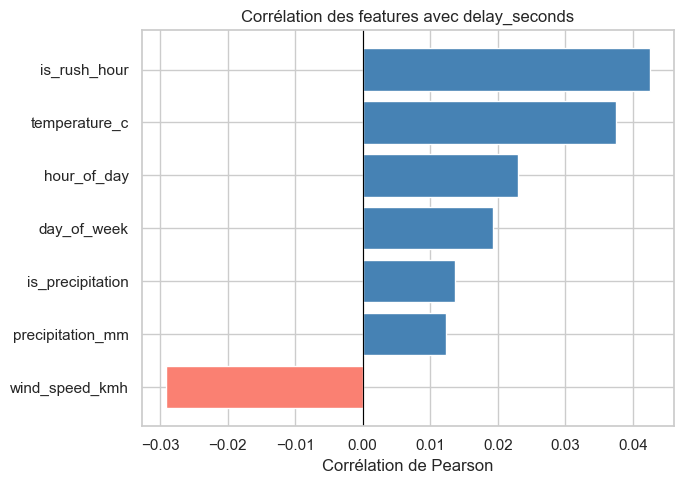

                  delay_seconds
wind_speed_kmh            -0.03
precipitation_mm           0.01
is_precipitation           0.01
day_of_week                0.02
hour_of_day                0.02
temperature_c              0.04
is_rush_hour               0.04
week_of_year                NaN


In [10]:
# Corrélations avec delay_seconds
df_clean = df_sample[df_sample['delay_seconds'].between(-600, 3600)].copy()
df_clean['is_rush_hour'] = df_clean['is_rush_hour'].astype(int)
df_clean['is_precipitation'] = df_clean['is_precipitation'].astype(int)

numeric_cols = ['hour_of_day', 'day_of_week', 'week_of_year', 'is_rush_hour',
                'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'is_precipitation',
                'delay_seconds']

corr = df_clean[numeric_cols].corr()[['delay_seconds']].drop('delay_seconds').sort_values('delay_seconds')

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['salmon' if v < 0 else 'steelblue' for v in corr['delay_seconds']]
ax.barh(corr.index, corr['delay_seconds'], color=colors)
ax.set_title('Corrélation des features avec delay_seconds')
ax.set_xlabel('Corrélation de Pearson')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print(corr)

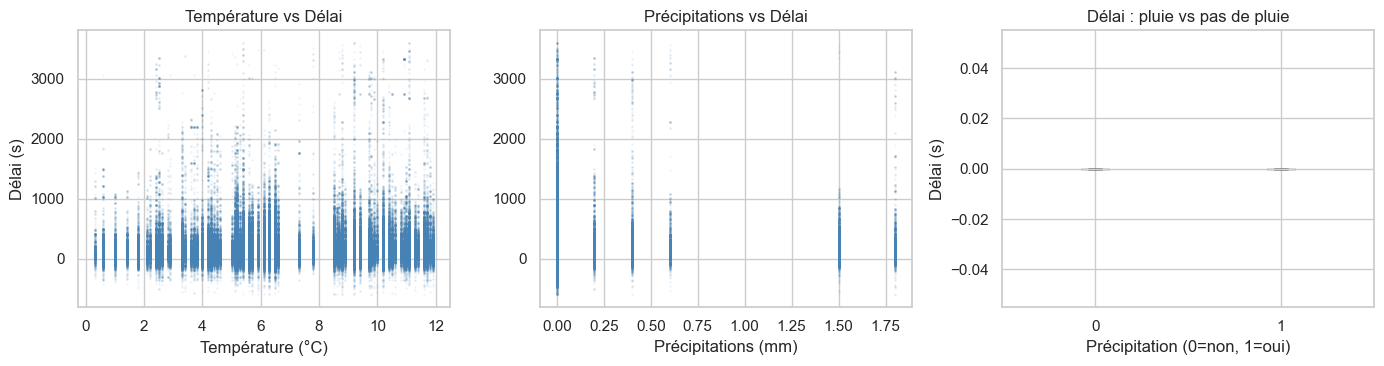

In [11]:
# Impact de la météo sur les délais
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Température
axes[0].scatter(df_clean['temperature_c'], df_clean['delay_seconds'],
                alpha=0.05, s=1, color='steelblue')
axes[0].set_title('Température vs Délai')
axes[0].set_xlabel('Température (°C)')
axes[0].set_ylabel('Délai (s)')

# Précipitations
axes[1].scatter(df_clean['precipitation_mm'], df_clean['delay_seconds'],
                alpha=0.05, s=1, color='steelblue')
axes[1].set_title('Précipitations vs Délai')
axes[1].set_xlabel('Précipitations (mm)')

# Avec/sans pluie (boxplot)
df_clean.boxplot(column='delay_seconds', by='is_precipitation', ax=axes[2],
                 showfliers=False, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[2].set_title('Délai : pluie vs pas de pluie')
axes[2].set_xlabel('Précipitation (0=non, 1=oui)')
axes[2].set_ylabel('Délai (s)')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 4. Génération du dataset final

> **Note sur le data leakage :** on ne fait PAS de train/test split ici. Le split sera fait chronologiquement dans le notebook d'entraînement (notebook 04). Ne jamais couper aléatoirement une série temporelle.

In [12]:
# Générer le dataset complet via features.py
import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

OUTPUT_PATH = '../data/features/dataset.parquet'

df = build_feature_dataset(output_path=OUTPUT_PATH)
print(f"\nDataset final : {len(df):,} lignes × {len(df.columns)} colonnes")

[Features] Lecture depuis v_delays_enriched...
[Features] 23485234 lignes brutes chargées
[Features] 39980 outliers supprimés (|delay| > 1h)
[Features] Échantillonné à 2,000,000 lignes (ordre chronologique conservé)
[Features] 2000000 lignes finales
[Features] Dataset exporté → ../data/features/dataset.parquet



Dataset final : 2,000,000 lignes × 11 colonnes


## 5. Validation du dataset

In [13]:
print("=== Statistiques descriptives ===")
df.describe()

=== Statistiques descriptives ===


,hour_of_day,day_of_week,week_of_year,is_rush_hour,temperature_c,precipitation_mm,wind_speed_kmh,is_precipitation,delay_seconds,route_id_encoded
count,2000000.00,2000000.00,2000000.00,2000000.00,2000000.00,2000000.00,2000000.00,2000000.00,2000000.00,2000000.00
mean,15.44,4.37,14.00,0.39,6.53,0.06,11.36,0.08,199.14,89.93
std,3.22,0.48,0.00,0.49,3.00,0.26,4.34,0.27,285.34,54.40
min,0.00,4.00,14.00,0.00,0.30,0.00,0.40,0.00,-600.00,0.00
25%,13.00,4.00,14.00,0.00,4.30,0.00,8.40,0.00,75.00,42.00
50%,16.00,4.00,14.00,0.00,6.10,0.00,11.50,0.00,114.00,81.00
75%,18.00,5.00,14.00,1.00,9.20,0.00,14.30,0.00,268.00,141.00
max,23.00,5.00,14.00,1.00,11.90,1.80,18.60,1.00,3600.00,187.00


In [14]:
print("=== Valeurs manquantes ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "Aucune valeur manquante ✓")

=== Valeurs manquantes ===
Aucune valeur manquante ✓


=== Distribution de la target ===


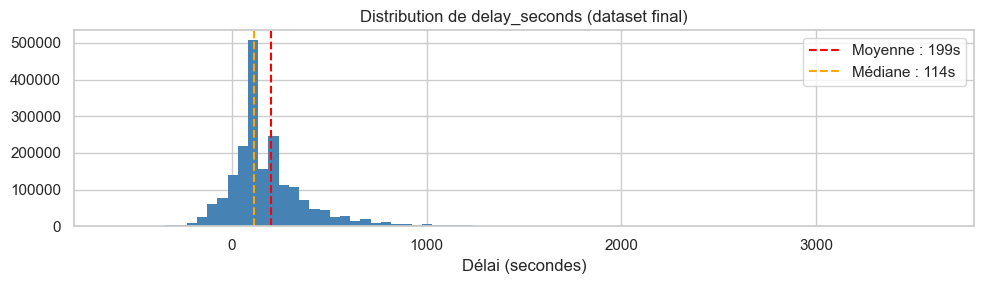

In [15]:
print("=== Distribution de la target ===")
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(df['delay_seconds'], bins=80, color='steelblue', edgecolor='none')
ax.axvline(df['delay_seconds'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['delay_seconds'].mean():.0f}s")
ax.axvline(df['delay_seconds'].median(), color='orange', linestyle='--', label=f"Médiane : {df['delay_seconds'].median():.0f}s")
ax.set_title('Distribution de delay_seconds (dataset final)')
ax.set_xlabel('Délai (secondes)')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
print("=== Nombre de lignes par ligne de bus ===")
route_counts = df['route_id_encoded'].value_counts()
print(f"Lignes de bus distinctes : {len(route_counts)}")
print(f"Min observations / ligne : {route_counts.min():,}")
print(f"Max observations / ligne : {route_counts.max():,}")
print(f"Médiane                  : {route_counts.median():,.0f}")

=== Nombre de lignes par ligne de bus ===
Lignes de bus distinctes : 188
Min observations / ligne : 3
Max observations / ligne : 78,462
Médiane                  : 7,082


In [17]:
# Vérification finale
import os
size_mb = os.path.getsize(OUTPUT_PATH) / 1024 / 1024
print(f"Fichier Parquet : {OUTPUT_PATH}")
print(f"Taille          : {size_mb:.1f} MB")
print(f"Lignes          : {len(df):,}")
print(f"Colonnes        : {list(df.columns)}")
print()
if len(df) >= 10_000:
    print("✓ Dataset suffisant pour l'entraînement (≥ 10 000 lignes)")
else:
    print(f"⚠ Seulement {len(df):,} lignes — collecte plus de données avant d'entraîner")

Fichier Parquet : ../data/features/dataset.parquet
Taille          : 8.6 MB
Lignes          : 2,000,000
Colonnes        : ['route_id', 'hour_of_day', 'day_of_week', 'week_of_year', 'is_rush_hour', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'is_precipitation', 'delay_seconds', 'route_id_encoded']

✓ Dataset suffisant pour l'entraînement (≥ 10 000 lignes)


## 6. Prochaines étapes

- [x] Dataset exporté dans `data/features/dataset.parquet`
- [ ] Ouvrir `04_model_evaluation.ipynb` pour entraîner XGBoost
- [ ] Démarrer MLflow : décommenter le service dans `docker-compose.yml`, puis `docker-compose up mlflow -d`